In [ ]:
!pip install opencv-python

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install cupy-cuda12x


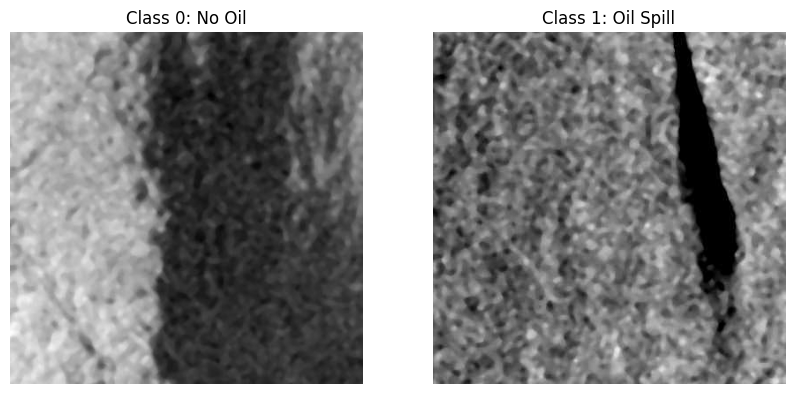

In [ ]:
import cv2
import os
import random
import matplotlib.pyplot as plt

# Define dataset paths
DATASET_PATH = r"/content/drive/MyDrive/oil spill data/SARS"  # Change this to your dataset folder
CLASS_0_PATH = os.path.join(DATASET_PATH, "0")  # Folder for No Oil
CLASS_1_PATH = os.path.join(DATASET_PATH, "1")  # Folder for Oil Spill

# Function to load and display random images from both classes
def display_images():
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Load a random Class 0 (No Oil) image
    no_oil_image = random.choice(os.listdir(CLASS_0_PATH))
    img_no_oil = cv2.imread(os.path.join(CLASS_0_PATH, no_oil_image), cv2.IMREAD_GRAYSCALE)

    # Load a random Class 1 (Oil Spill) image
    oil_spill_image = random.choice(os.listdir(CLASS_1_PATH))
    img_oil_spill = cv2.imread(os.path.join(CLASS_1_PATH, oil_spill_image), cv2.IMREAD_GRAYSCALE)

    # Display images
    axes[0].imshow(img_no_oil, cmap='gray')
    axes[0].set_title("Class 0: No Oil")

    axes[1].imshow(img_oil_spill, cmap='gray')
    axes[1].set_title("Class 1: Oil Spill")

    for ax in axes:
        ax.axis("off")

    plt.show()

# Run the function
display_images()

In [ ]:
!pip install opencv-contrib-python


In [ ]:
!pip uninstall opencv-python opencv-python-headless -y


Found existing installation: opencv-python 4.11.0.86
Uninstalling opencv-python-4.11.0.86:
  Successfully uninstalled opencv-python-4.11.0.86
Found existing installation: opencv-python-headless 4.11.0.86
Uninstalling opencv-python-headless-4.11.0.86:
  Successfully uninstalled opencv-python-headless-4.11.0.86


In [ ]:
!pip install opencv-contrib-python-headless


In [ ]:
import os
import cv2
import numpy as np
import cupy as cp  # GPU-accelerated NumPy
from joblib import Parallel, delayed
from skimage.restoration import denoise_bilateral
import torch

# Define paths
DATASET_PATH = r"/content/drive/MyDrive/oil spill data/SARS"
OUTPUT_PATH = r"/content/drive/MyDrive/oil spill data/SARS output"

# Create output folders
os.makedirs(os.path.join(OUTPUT_PATH, "0"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, "1"), exist_ok=True)

# Check if CUDA is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Function to preprocess a single image with CUDA acceleration
def preprocess_image_gpu(img_path, save_path):
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        return  # Skip if image is corrupted

    # Resize to 400x400
    image = cv2.resize(image, (400, 400))

    # Convert to float32 and normalize (0 to 1)
    image = image.astype(np.float32) / 255.0

    # Apply Histogram Equalization
    image_hist_eq = cv2.equalizeHist((image * 255).astype(np.uint8))

    # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_clahe = clahe.apply((image * 255).astype(np.uint8))

    # Convert to CuPy array (GPU)
    image_gpu = cp.array(image_clahe, dtype=cp.float32)

    # Apply CUDA-accelerated Median Filtering
    image_gpu = cp.asarray(image_gpu)  # Ensure it's a CuPy array
    image_median_filtered = cv2.cuda.createMedianFilter(cv2.CV_8UC1, 3)
    image_median_filtered = image_median_filtered.apply(cp.asnumpy(image_gpu))

    # Apply CUDA-accelerated Bilateral Filtering
    image_bilateral = cv2.cuda.createBilateralFilter(9, 75, 75, cv2.CV_8UC1)
    image_bilateral = image_bilateral.apply(image_median_filtered)

    # Convert back to NumPy
    image_bilateral = cp.asnumpy(image_bilateral)

    # Save the processed image
    cv2.imwrite(save_path, image_bilateral)

# Function to process all images in a folder using parallel GPU processing
def process_folder_gpu(class_name):
    input_folder = os.path.join(DATASET_PATH, class_name)
    output_folder = os.path.join(OUTPUT_PATH, class_name)

    # Get all image files
    image_files = [f for f in os.listdir(input_folder) if f.endswith(".jpg")]

    # Process images in parallel
    Parallel(n_jobs=-1)(  # Use all available CPU cores to schedule GPU jobs
        delayed(preprocess_image_gpu)(os.path.join(input_folder, img_file), os.path.join(output_folder, img_file))
        for img_file in image_files
    )

    print(f"✅ Processed {len(image_files)} images in Class {class_name} using CUDA!")

# Run preprocessing for both classes in parallel
process_folder_gpu("0")
process_folder_gpu("1")

print("🚀 GPU-Accelerated Batch Preprocessing Completed!")

Using device: cuda


AttributeError: module 'cv2.cuda' has no attribute 'createMedianFilter'

In [ ]:
X = X.reshape(-1, 128, 128, 1)  # Adding channel dimension
print(f"✅ Final X shape: {X.shape}")  # Should be (5630, 128, 128, 1)



In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Convert labels to categorical (one-hot encoding)
y = to_categorical(y, num_classes=2)

# Split dataset
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Training set: {X_train.shape[0]} images, Validation set: {X_val.shape[0]} images")


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Regularization to prevent overfitting
    Dense(2, activation='softmax')  # Output layer (2 classes: Oil Spill / No Oil)
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,  # Increase epochs for better accuracy
    batch_size=32,
    verbose=1
)


In [ ]:
# Evaluate on validation set
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"✅ Validation Accuracy: {val_acc*100:.2f}%")


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from skimage.restoration import denoise_bilateral
import matplotlib.pyplot as plt

# Load the trained model
model = tf.keras.models.load_model("/content/drive/MyDrive/oil spill data/h5 file/oil_spill_detector.h5")

# Preprocessing function (same as before)
def preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (128, 128))
    image = image.astype(np.float32) / 255.0

    # Apply CLAHE and Bilateral Filtering
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_clahe = clahe.apply((image * 255).astype(np.uint8))
    image_bilateral = denoise_bilateral(image_clahe, sigma_color=0.05, sigma_spatial=15, channel_axis=None)

    return image_bilateral.reshape(1, 128, 128, 1)  # Model expects 4D input

# Function to mark oil spill boundaries
def mark_boundaries(image_path):
    # Read and preprocess the image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    processed_img = preprocess_image(image_path)

    # Predict using the model
    prediction = model.predict(processed_img)

    if np.argmax(prediction) == 1:  # Oil spill detected
        print("🚨 Oil Spill Detected!")

        # Thresholding to isolate spill regions
        _, thresholded = cv2.threshold(image, 50, 255, cv2.THRESH_BINARY)

        # Find and draw contours (boundaries)
        contours, _ = cv2.findContours(thresholded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        marked_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        cv2.drawContours(marked_image, contours, -1, (0, 0, 255), 2)  # Red boundary

        # Display results
        plt.figure(figsize=(6, 6))
        plt.imshow(marked_image, cmap='gray')
        plt.title("Oil Spill Detected with Boundaries")
        plt.axis('off')
        plt.show()
    else:
        print("✅ No Oil Spill Detected.")

# Example Usage
image_path = "/content/Untitled Folder/0_0_0_img_QU4PTDLBV3dBxN7b_PHI_cls_0.jpg"
mark_boundaries(image_path)
